# Ruvims Ungeitis, st84951, 4301bna,Variant 2

# Introduction

# 1. Import tools and file

In [1]:
# installing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan, het_goldfeldquandt
from statsmodels.stats.stattools import durbin_watson

# loading the data
data = pd.read_excel('ChangedFile.xlsx')
data.head()

,Rate,Survived,Total,Failed,new_column,new_column2
0,1,yes,7287,1,166.260,166.260
1,2,no,4634,0,136.987,136.987
2,3,yes,5769,1,184.101,184.101
3,3,yes,1870,1,130.129,130.129
4,2,no,3697,0,156.878,156.878


# 1.2 Data check

In [2]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rate         100 non-null    int64  
 1   Survived     100 non-null    object 
 2   Total        100 non-null    int64  
 3   Failed       100 non-null    int64  
 4   new_column   100 non-null    float64
 5   new_column2  93 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 4.8+ KB


Rate           0
Survived       0
Total          0
Failed         0
new_column     0
new_column2    7
dtype: int64

# 1.3 Droping nulls

In [3]:
newTable = data.dropna()
newTable.info()
newTable.describe()
newTable.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 93 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rate         93 non-null     int64  
 1   Survived     93 non-null     object 
 2   Total        93 non-null     int64  
 3   Failed       93 non-null     int64  
 4   new_column   93 non-null     float64
 5   new_column2  93 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 5.1+ KB


Rate           0
Survived       0
Total          0
Failed         0
new_column     0
new_column2    0
dtype: int64

# 2. Construct the multipme regression and analyse

# 2.1 Models quality parameters and t-test

In [4]:
y = newTable['Rate']
x = newTable[['Total', 'new_column', 'new_column2']]

model = smf.ols("Rate ~ Total + new_column + new_column2", data=newTable).fit()

print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     2.742
Date:                Wed, 20 May 2026   Prob (F-statistic):             0.0698
Time:                        12:09:52   Log-Likelihood:                -164.81
No. Observations:                  93   AIC:                             335.6
Df Residuals:                      90   BIC:                             343.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.9101      0.709      4.106      

The initial model has low explanatory power. Total is statistically significant, while new_column and new_column2 are not. The model also shows possible multicollinearity, probably because new_column and new_column2 contain very similar information.

# 2.2 Residual analysis (Gauss-Markov condition)

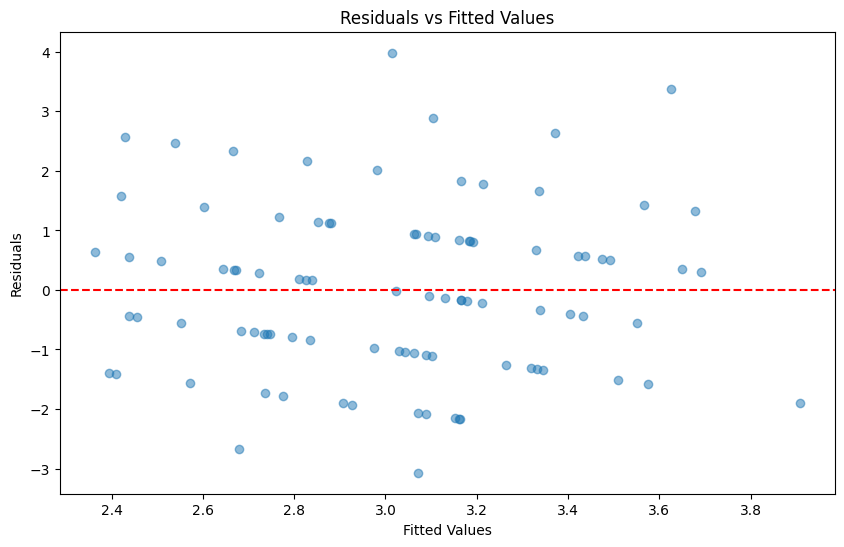

In [5]:
residuals = model.resid
fitted_values = model.fittedvalues

plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

The residuals are located around the zero line, but the plot shows a slight pattern and the spread becomes larger for some fitted values. This may indicate non-constant variance. There is also at least one extreme point, so outliers should be checked.

# Check normalisation by Q-Q plot

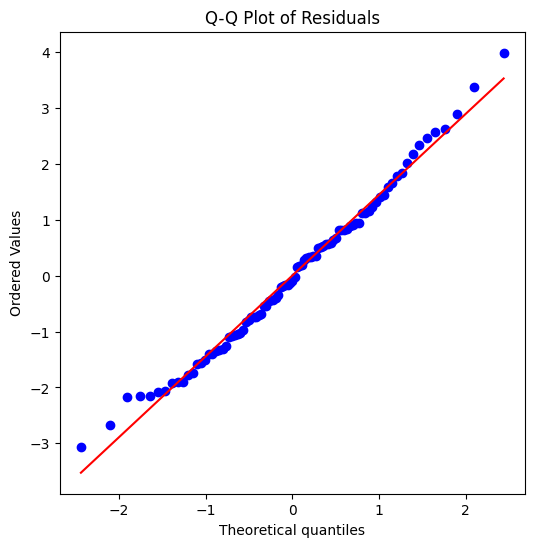

In [6]:
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

The residuals are approximately normal because most points follow the diagonal line. However, there is some deviation in the tail, which may indicate an outlier.

# 3. Find outliers

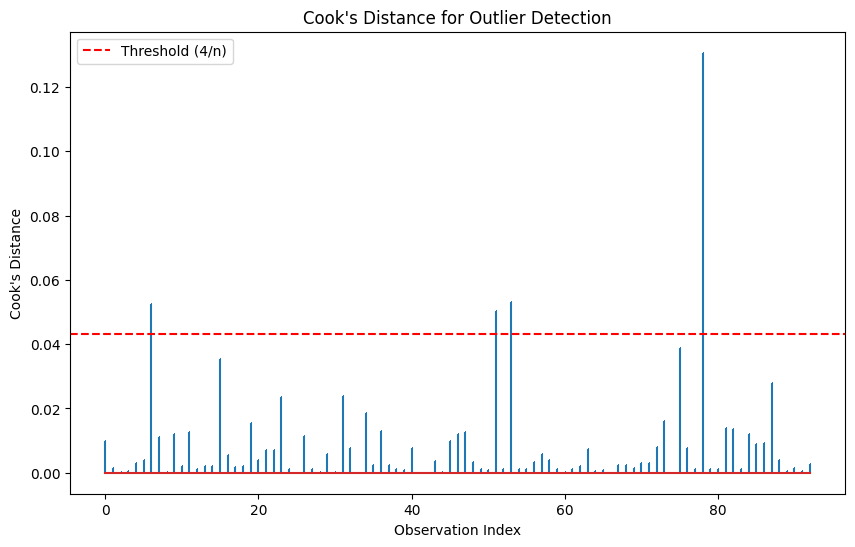

Potential outliers at indices: [ 6  9 36 51 53 75 78]


In [7]:
# Calculate standardized residuals
influence = OLSInfluence(model)
standardized_residuals = influence.resid_studentized_internal

# Calculate Cook's distance
cooks_d = influence.cooks_distance[0]

# Plot Cook's distance
plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(4 / len(cooks_d), color='red', linestyle='--', label="Threshold (4/n)")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Outlier Detection")
plt.legend()
plt.show()

# Identify potential outliers
outliers = np.where((np.abs(standardized_residuals) > 2) | (cooks_d > 4 / len(cooks_d)))[0]
print(f"Potential outliers at indices: {outliers}")

# 4.1 removing outliers

Removed outliers:
1. position=78, index=84, Cook's distance=0.1307, standardized residual=2.4334
2. position=53, index=59, Cook's distance=0.0690, standardized residual=1.7515
3. position=74, index=81, Cook's distance=0.0412, standardized residual=2.8488
4. position=51, index=57, Cook's distance=0.0446, standardized residual=-1.2237
5. position=6, index=7, Cook's distance=0.0514, standardized residual=-1.2858
6. position=14, index=16, Cook's distance=0.0475, standardized residual=2.0310
7. position=29, index=35, Cook's distance=0.0376, standardized residual=2.0564
8. position=31, index=38, Cook's distance=0.0291, standardized residual=2.1212
9. position=67, index=79, Cook's distance=0.0294, standardized residual=2.0682
10. position=8, index=10, Cook's distance=0.0206, standardized residual=2.5239
11. position=20, index=25, Cook's distance=0.0337, standardized residual=-2.0426
12. position=30, index=40, Cook's distance=0.0221, standardized residual=-2.5193
13. position=75, index=94, Coo

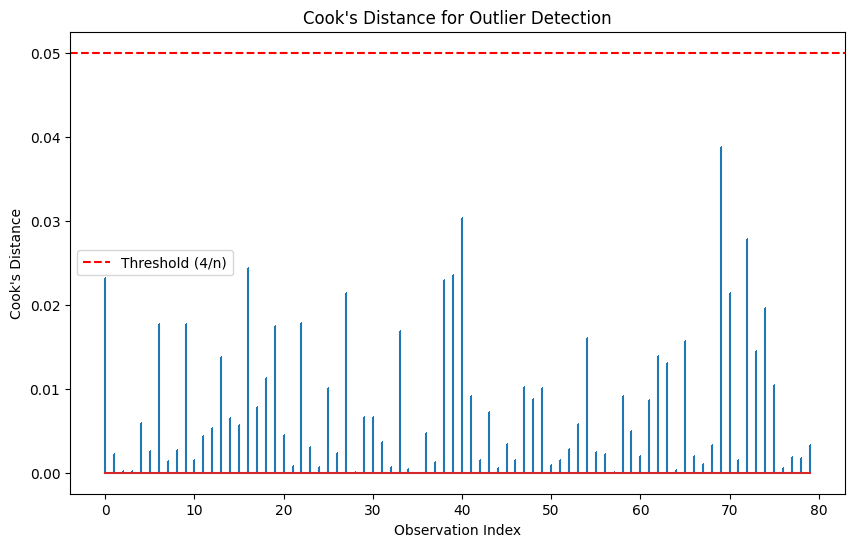

In [8]:
clean_table = newTable.copy()
removed_outliers = []

while True:
    current_model = smf.ols(
        "Rate ~ Total + new_column + new_column2",
        data=clean_table
    ).fit()

    influence = OLSInfluence(current_model)
    standardized_residuals = np.asarray(influence.resid_studentized_internal)
    cooks_d_current = np.asarray(influence.cooks_distance[0])

    threshold = 4 / len(clean_table)

    outliers_current = np.where(
        (np.abs(standardized_residuals) > 2) |
        (cooks_d_current > threshold)
    )[0]

    if len(outliers_current) == 0:
        break

    largest_outlier_position = outliers_current[np.argmax(cooks_d_current[outliers_current])]
    largest_outlier_index = clean_table.index[largest_outlier_position]

    removed_outliers.append({
        "position": int(largest_outlier_position),
        "index": int(largest_outlier_index),
        "cooks_distance": float(cooks_d_current[largest_outlier_position]),
        "standardized_residual": float(standardized_residuals[largest_outlier_position])
    })

    clean_table = clean_table.drop(index=largest_outlier_index)

print("Removed outliers:")
for i, item in enumerate(removed_outliers, start=1):
    print(
        f"{i}. position={item['position']}, "
        f"index={item['index']}, "
        f"Cook's distance={item['cooks_distance']:.4f}, "
        f"standardized residual={item['standardized_residual']:.4f}"
    )

print(f"Rows before removing outliers: {len(newTable)}")
print(f"Rows after removing outliers: {len(clean_table)}")

plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(cooks_d_current)), cooks_d_current, markerfmt=",")
plt.axhline(4 / len(cooks_d_current), color='red', linestyle='--', label="Threshold (4/n)")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Outlier Detection")
plt.legend()
plt.show()


Outliers were removed one by one. At each step, the model was rebuilt, Cook's distance was recalculated, and only the most influential remaining observation was removed.


In [9]:
model_clean = smf.ols(
    "Rate ~ Total + new_column + new_column2",
    data=clean_table
).fit()

print(model_clean.summary())


                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     4.982
Date:                Wed, 20 May 2026   Prob (F-statistic):            0.00923
Time:                        12:09:53   Log-Likelihood:                -119.90
No. Observations:                  80   AIC:                             245.8
Df Residuals:                      77   BIC:                             252.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.3899      0.622      3.843      

# 4.2 Removing insignificant variables
After removing outliers, insignificant predictors are removed one by one. Since `new_column` and `new_column2` have the same p-value and are highly similar, `new_column2` is removed first.


In [10]:
model_reduced1 = smf.ols(
    "Rate ~ Total + new_column",
    data=clean_table
).fit()

model_reduced2 = smf.ols(
    "Rate ~ Total",
    data=clean_table
).fit()

comparison = pd.DataFrame({
    "Model": [
        "Clean model",
        "Without new_column2",
        "Only Total"
    ],
    "Predictors": [
        "Total + new_column + new_column2",
        "Total + new_column",
        "Total"
    ],
    "Adj. R-squared": [
        model_clean.rsquared_adj,
        model_reduced1.rsquared_adj,
        model_reduced2.rsquared_adj
    ],
    "AIC": [
        model_clean.aic,
        model_reduced1.aic,
        model_reduced2.aic
    ],
    "BIC": [
        model_clean.bic,
        model_reduced1.bic,
        model_reduced2.bic
    ]
})

comparison


,Model,Predictors,Adj. R-squared,AIC,BIC
0,Clean model,Total + new_column + new_column2,0.091573,245.799081,252.945161
1,Without new_column2,Total + new_column,0.091573,245.799081,252.945161
2,Only Total,Total,0.060778,247.498344,252.262397


In [11]:
print(model_reduced1.summary())


                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     4.982
Date:                Wed, 20 May 2026   Prob (F-statistic):            0.00923
Time:                        12:09:53   Log-Likelihood:                -119.90
No. Observations:                  80   AIC:                             245.8
Df Residuals:                      77   BIC:                             252.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3899      0.622      3.843      0.0

In [12]:
print(model_reduced2.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     6.112
Date:                Wed, 20 May 2026   Prob (F-statistic):             0.0156
Time:                        12:09:53   Log-Likelihood:                -121.75
No. Observations:                  80   AIC:                             247.5
Df Residuals:                      78   BIC:                             252.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4670      0.266     13.040      0.0

The reduced models are compared using adjusted R-squared, AIC, BIC, and predictor p-values. The preferred model should keep significant predictors while avoiding unnecessary duplicate variables.


# 5 Non-linear models

In [13]:
nonLinear_model = smf.ols('Rate ~ Total + new_column + I(Total**2) + I(new_column**2)', data=clean_table).fit()
print(nonLinear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     2.762
Date:                Wed, 20 May 2026   Prob (F-statistic):             0.0336
Time:                        12:09:53   Log-Likelihood:                -119.27
No. Observations:                  80   AIC:                             248.5
Df Residuals:                      75   BIC:                             260.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.3173      2

In [14]:
logarithmic_model = smf.ols('Rate ~ np.log(Total) + np.log(new_column)', data=clean_table).fit()

print(logarithmic_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     5.662
Date:                Wed, 20 May 2026   Prob (F-statistic):            0.00508
Time:                        12:09:53   Log-Likelihood:                -119.28
No. Observations:                  80   AIC:                             244.6
Df Residuals:                      77   BIC:                             251.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.4389      3

# 6. Stepwise model selection
Forward stepwise starts with an empty model and adds predictors if they improve AIC. Backward stepwise starts with the full model and removes predictors if this improves AIC.


In [15]:
candidate_predictors = ["Total", "new_column", "new_column2"]
response = "Rate"

def forward_stepwise(data, response, predictors):
    selected = []
    remaining = predictors.copy()
    current_model = smf.ols(f"{response} ~ 1", data=data).fit()
    current_aic = current_model.aic
    final_model = current_model

    while remaining:
        results = []

        for predictor in remaining:
            formula = response + " ~ " + " + ".join(selected + [predictor])
            model = smf.ols(formula, data=data).fit()
            results.append((model.aic, predictor, model))

        results.sort(key=lambda item: item[0])
        best_aic, best_predictor, best_model = results[0]

        if best_aic < current_aic:
            selected.append(best_predictor)
            remaining.remove(best_predictor)
            current_aic = best_aic
            final_model = best_model
            print("Added:", best_predictor, "AIC:", round(best_aic, 3))
        else:
            break

    return final_model, selected

def backward_stepwise(data, response, predictors):
    selected = predictors.copy()
    current_formula = response + " ~ " + " + ".join(selected)
    current_model = smf.ols(current_formula, data=data).fit()
    current_aic = current_model.aic

    while len(selected) > 1:
        results = []

        for predictor in selected:
            trial_predictors = selected.copy()
            trial_predictors.remove(predictor)
            formula = response + " ~ " + " + ".join(trial_predictors)
            model = smf.ols(formula, data=data).fit()
            results.append((model.aic, predictor, model, trial_predictors))

        results.sort(key=lambda item: item[0])
        best_aic, removed_predictor, best_model, best_predictors = results[0]

        if best_aic < current_aic:
            selected = best_predictors
            current_aic = best_aic
            current_model = best_model
            print("Removed:", removed_predictor, "AIC:", round(best_aic, 3))
        else:
            break

    return current_model, selected


In [16]:
forward_model, forward_predictors = forward_stepwise(
    clean_table,
    response,
    candidate_predictors
)

backward_model, backward_predictors = backward_stepwise(
    clean_table,
    response,
    candidate_predictors
)

print("Forward selected predictors:", forward_predictors)
print("Backward selected predictors:", backward_predictors)


Added: Total AIC: 247.498
Added: new_column AIC: 245.799
Forward selected predictors: ['Total', 'new_column']
Backward selected predictors: ['Total', 'new_column', 'new_column2']


In [17]:
print(forward_model.summary())
print(backward_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     4.982
Date:                Wed, 20 May 2026   Prob (F-statistic):            0.00923
Time:                        12:09:53   Log-Likelihood:                -119.90
No. Observations:                  80   AIC:                             245.8
Df Residuals:                      77   BIC:                             252.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3899      0.622      3.843      0.0

In [18]:
stepwise_comparison = pd.DataFrame({
    "Model": ["Forward stepwise", "Backward stepwise"],
    "Predictors": [
        " + ".join(forward_predictors) if forward_predictors else "Intercept only",
        " + ".join(backward_predictors) if backward_predictors else "Intercept only"
    ],
    "Adj. R-squared": [
        forward_model.rsquared_adj,
        backward_model.rsquared_adj
    ],
    "AIC": [
        forward_model.aic,
        backward_model.aic
    ],
    "BIC": [
        forward_model.bic,
        backward_model.bic
    ]
})

stepwise_comparison


,Model,Predictors,Adj. R-squared,AIC,BIC
0,Forward stepwise,Total + new_column,0.091573,245.799081,252.945161
1,Backward stepwise,Total + new_column + new_column2,0.091573,245.799081,252.945161


The forward and backward models are compared using adjusted R-squared, AIC, and BIC. The preferred stepwise model is the one with lower AIC/BIC and a simpler set of predictors.


# 7. Final model comparison
All observed models are compared using adjusted R-squared, AIC, and BIC. A better model should have higher adjusted R-squared and lower AIC/BIC, while also remaining reasonably simple.


In [19]:
final_comparison = pd.DataFrame({
    "Model": [
        "Initial model",
        "Cleaned model",
        "Reduced linear model",
        "Total-only model",
        "Quadratic model",
        "Logarithmic model",
        "Forward stepwise",
        "Backward stepwise"
    ],
    "Predictors": [
        "Total + new_column + new_column2",
        "Total + new_column + new_column2",
        "Total + new_column",
        "Total",
        "Total + new_column + Total^2 + new_column^2",
        "ln(Total) + ln(new_column)",
        " + ".join(forward_predictors),
        " + ".join(backward_predictors)
    ],
    "Adj. R-squared": [
        model.rsquared_adj,
        model_clean.rsquared_adj,
        model_reduced1.rsquared_adj,
        model_reduced2.rsquared_adj,
        nonLinear_model.rsquared_adj,
        logarithmic_model.rsquared_adj,
        forward_model.rsquared_adj,
        backward_model.rsquared_adj
    ],
    "AIC": [
        model.aic,
        model_clean.aic,
        model_reduced1.aic,
        model_reduced2.aic,
        nonLinear_model.aic,
        logarithmic_model.aic,
        forward_model.aic,
        backward_model.aic
    ],
    "BIC": [
        model.bic,
        model_clean.bic,
        model_reduced1.bic,
        model_reduced2.bic,
        nonLinear_model.bic,
        logarithmic_model.bic,
        forward_model.bic,
        backward_model.bic
    ]
})

final_comparison.sort_values("AIC")


,Model,Predictors,Adj. R-squared,AIC,BIC
5,Logarithmic model,ln(Total) + ln(new_column),0.105556,244.558090,251.704170
1,Cleaned model,Total + new_column + new_column2,0.091573,245.799081,252.945161
2,Reduced linear model,Total + new_column,0.091573,245.799081,252.945161
6,Forward stepwise,Total + new_column,0.091573,245.799081,252.945161
7,Backward stepwise,Total + new_column + new_column2,0.091573,245.799081,252.945161
3,Total-only model,Total,0.060778,247.498344,252.262397
4,Quadratic model,Total + new_column + Total^2 + new_column^2,0.081891,248.541844,260.451977
0,Initial model,Total + new_column + new_column2,0.036482,335.614034,343.211833


According to the comparison, the logarithmic model is selected as the best model. It has the lowest AIC/BIC and the highest adjusted R-squared among the tested models. Therefore, the final model explains `Rate` using `ln(Total)` and `ln(new_column)`.


# 8. Optional diagnostic tests for the selected model


In [20]:
final_model = logarithmic_model

bp_test = het_breuschpagan(final_model.resid, final_model.model.exog)
gq_test = het_goldfeldquandt(final_model.resid, final_model.model.exog)
dw_value = durbin_watson(final_model.resid)

diagnostic_tests = pd.DataFrame({
    "Test": [
        "Breusch-Pagan heteroscedasticity test",
        "Goldfeld-Quandt heteroscedasticity test",
        "Durbin-Watson autocorrelation statistic"
    ],
    "Statistic": [
        bp_test[0],
        gq_test[0],
        dw_value
    ],
    "p-value": [
        bp_test[1],
        gq_test[1],
        np.nan
    ]
})

diagnostic_tests


,Test,Statistic,p-value
0,Breusch-Pagan heteroscedasticity test,0.327313,0.849034
1,Goldfeld-Quandt heteroscedasticity test,0.825962,0.718091
2,Durbin-Watson autocorrelation statistic,1.839812,NaN


In [ ]:
# optional_task_interpretation
bp_pvalue = bp_test[1]
gq_pvalue = gq_test[1]

print("Optional task interpretation:")

if bp_pvalue < 0.05:
    print("Breusch-Pagan test: p-value is below 0.05, so heteroscedasticity may be present.")
else:
    print("Breusch-Pagan test: p-value is above 0.05, so there is no strong evidence of heteroscedasticity.")

if gq_pvalue < 0.05:
    print("Goldfeld-Quandt test: p-value is below 0.05, so heteroscedasticity may be present.")
else:
    print("Goldfeld-Quandt test: p-value is above 0.05, so there is no strong evidence of heteroscedasticity.")

if 1.5 <= dw_value <= 2.5:
    print("Durbin-Watson statistic is close to 2, so there is no strong evidence of autocorrelation.")
else:
    print("Durbin-Watson statistic is far from 2, so autocorrelation may be present.")


For the selected logarithmic model, both heteroscedasticity tests have p-values above 0.05, so there is no strong evidence of heteroscedasticity. The Durbin-Watson statistic is close to 2, so there is no strong evidence of autocorrelation. Therefore, the optional diagnostic tests do not indicate serious violations for the final model.


The optional tests are used to check additional regression assumptions. For the Breusch-Pagan and Goldfeld-Quandt tests, a p-value below 0.05 indicates possible heteroscedasticity. The Durbin-Watson statistic is used to check autocorrelation; a value close to 2 suggests no strong autocorrelation.


# 9. Conclusions
The initial multiple regression model had low explanatory power and showed insignificant predictors. Residual diagnostics indicated possible influential observations, so outliers were detected using standardized residuals and Cook's distance. Outliers were removed one by one, and the model was rebuilt after every removal.

After removing outliers, insignificant and duplicate predictors were examined. `new_column2` did not improve the model because it duplicated the information in `new_column`. Linear, quadratic, logarithmic, forward stepwise, and backward stepwise models were then compared.

The logarithmic model was selected as the best final model because it had the highest adjusted R-squared and the lowest AIC/BIC among the observed models. The final model is: `Rate ~ ln(Total) + ln(new_column)`.
